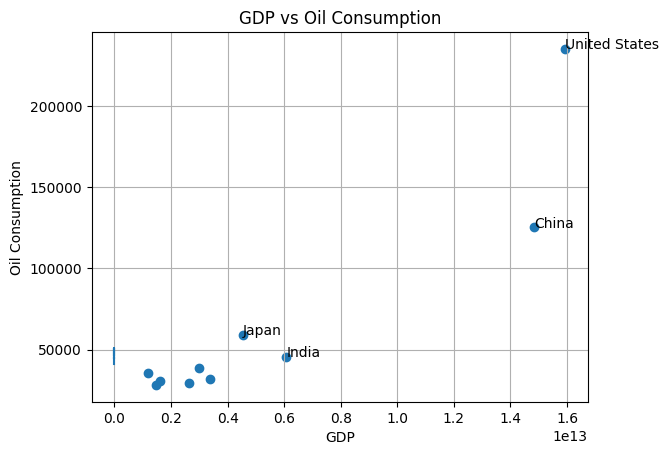

Japan GDP promedio: 4.55 trillion USD
India GDP promedio: 6.08 trillion USD
Japan oil avg: 2573
India oil avg: 1985


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import requests
from io import StringIO

url = "https://owid-public.owid.io/data/energy/owid-energy-data.csv"

headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)

df = pd.read_csv(StringIO(response.text))
df = df[df['year'] >= 2000]
df = df[['year','country','iso_code','oil_consumption','gas_consumption','population','gdp']]
df = df.dropna()
df = df[~df['iso_code'].str.startswith('OWID')]
df.head()
df.describe()

oil_trend = df.groupby('year')['oil_consumption'].sum()
oil_trend.plot(title='Global Oil Consumption Over Time')

import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('energy', conn, index=False)
query = """
SELECT country, SUM(oil_consumption) as total_oil
FROM energy
GROUP BY country
ORDER BY total_oil DESC
LIMIT 10;
"""

top_countries = pd.read_sql(query, conn)
top_countries

query = """
SELECT country,
       SUM(oil_consumption) as total_oil,
       AVG(gdp) as avg_gdp
FROM energy
GROUP BY country
ORDER BY total_oil DESC
LIMIT 10;
"""

df_gdp = pd.read_sql(query, conn)
df_gdp

import matplotlib.pyplot as plt

plt.scatter(df_gdp['avg_gdp'], df_gdp['total_oil'])
plt.xlabel('GDP')
plt.ylabel('Oil Consumption')
plt.title('GDP vs Oil Consumption')
plt.grid(True)
for i in range(4):  # top 4
    plt.text(df_gdp['avg_gdp'][i],
             df_gdp['total_oil'][i],
             df_gdp['country'][i])
plt.show()

#tamaño promedio eco japon vs india 00-22
df_japan = df[df['country'] == 'Japan']
df_india = df[df['country'] == 'India']
japan_gdp = df_japan['gdp'].mean() / 1e12
india_gdp = df_india['gdp'].mean() / 1e12

print(f"Japan GDP promedio: {japan_gdp:.2f} trillion USD")
print(f"India GDP promedio: {india_gdp:.2f} trillion USD")

#consumo petroleo promedio japon vs india 00-22
japan_oil=df_japan['oil_consumption'].mean()
india_oil=df_india['oil_consumption'].mean()
print(f"Japan oil avg: {japan_oil:.0f}")
print(f"India oil avg: {india_oil:.0f}")

df.to_csv('energy_clean.csv', index=False)
from google.colab import files
files.download('energy_clean.csv')

